# Exploratory Data Analysis - Intro to Pandas
EDA isnot a specific algorithm or model, it simply is a process of understanding, filtering, visualizing, exploring the dataset. Before training any model it is absolute necessary to understand the dataset, handle duplicates or missing values, etc. This entire exploration of dataset is called EDA.

EDA can be done with many libraries but mostly used libraries are : for data manipulation Pandas and for data visualization Seaborn or matplotlib.

In [1]:
# Import the Pandas library
import pandas as pd
# Import the Seaborn library for plotting
#!pip install seaborn
import seaborn as sns

# 2. Importing the Data
We will be working with a dataset called "world_happiness.csv" 

In [3]:
# Load the dataset and save it to the df variable
df = pd.read_csv('datasets/world_happiness.csv')

# 3. Basic Operations With a Dataframe

## 3.1 View the Dataframe
we can use `DataFrame.head()` and `DataFrame.tail()` to view the first or last rows of the frame respectively. By default it will show us five rows, but we can specify the number of rows we want to see as a parameter. Technically, neither of the functions actually display anything, but just return a new dataframe. The dataframe is displayed because Jupyter notebooks show the output of the last row in the cell. we can also display the contents of our dataframe by simply writing `df`. If our dataframe is too long, it will then display only the first and the last few rows.

Note that all of this only works if we use it in the last line of code in the cell, because the cells automatically display the output of the last line. If we want to see more than one dataframe by running a single cell or if we want to perform some other tasks after displaying the dataframe, then we better encapsulate it with `print()` or `display()`. `display()` function will print the dataframe, but with the same format as just calling `df`, whereas `print()` will print as plain text. 

In [ ]:
# This line will display the first few rows of the dataframe if there are no lines of code after.
# df.head()
# print(df.head())
# print(df)
display(df.head())

,Country name,year,Life Ladder,Log GDP per capita,Social support,Healthy life expectancy at birth,Freedom to make life choices,Generosity,Perceptions of corruption,Positive affect,Negative affect
0,Afghanistan,2008,3.724,7.350,0.451,50.5,0.718,0.168,0.882,0.414,0.258
1,Afghanistan,2009,4.402,7.509,0.552,50.8,0.679,0.191,0.850,0.481,0.237
2,Afghanistan,2010,4.758,7.614,0.539,51.1,0.600,0.121,0.707,0.517,0.275
3,Afghanistan,2011,3.832,7.581,0.521,51.4,0.496,0.164,0.731,0.480,0.267
4,Afghanistan,2012,3.783,7.661,0.521,51.7,0.531,0.238,0.776,0.614,0.268


In [7]:
# This line will display only the last two rows of the dataframe.
df.tail(2)

,Country name,year,Life Ladder,Log GDP per capita,Social support,Healthy life expectancy at birth,Freedom to make life choices,Generosity,Perceptions of corruption,Positive affect,Negative affect
2197,Zimbabwe,2021,3.155,7.657,0.685,54.050,0.668,-0.076,0.757,0.610,0.242
2198,Zimbabwe,2022,3.296,7.670,0.666,54.525,0.652,-0.070,0.753,0.641,0.191


## 3.2 Index and Column Names
In the `DataFrame`, the data is stored in a two dimensional grid (rows and columns). The rows are indexed and the columns are named. To see the index or the column names, we can use `DataFrame.index` or `DataFrame.columns` respectively.

In [8]:
df.index

RangeIndex(start=0, stop=2199, step=1)

As we can see, the index is a range of numbers between 0 (inclusive) and 2199 (not inclusive).

In [9]:
df.columns

Index(['Country name', 'year', 'Life Ladder', 'Log GDP per capita',
       'Social support', 'Healthy life expectancy at birth',
       'Freedom to make life choices', 'Generosity',
       'Perceptions of corruption', 'Positive affect', 'Negative affect'],
      dtype='str')

The column names are saved as strings. As we can see, they can include spaces. This can lead to difficulties when accessing the columns (we will see this very soon), so it is a good idea to rename them to get rid of the spaces. A common practice is to replace them with underscores. To rename the columns, we can use `DataFrame.rename()` and pass the columns we want to rename in a dictionary.

In the next example, we will see how we can automatically replace all spaces with underscores

In [17]:
# A dictionary mapping old column names to new column names. In addition to replacing spaces
# with underscores, we will make all of the text lowercase.
columns_to_rename = {i: "_".join(i.split(" ")).lower() for i in df.columns}
# Note that this dictionary is created automatically from the column names.
# we can also create it by hand and rename only the columns we want to rename
# For example, see the commented line below:
# columns_to_rename = {"Country name": "country_name", "Life Ladder": "life_ladder"}

# Rename the columns
df = df.rename(columns=columns_to_rename)
# Display the new dataframe
df.head()

,country_name,year,life_ladder,log_gdp_per_capita,social_support,healthy_life_expectancy_at_birth,freedom_to_make_life_choices,generosity,perceptions_of_corruption,positive_affect,negative_affect
0,Afghanistan,2008,3.724,7.350,0.451,50.5,0.718,0.168,0.882,0.414,0.258
1,Afghanistan,2009,4.402,7.509,0.552,50.8,0.679,0.191,0.850,0.481,0.237
2,Afghanistan,2010,4.758,7.614,0.539,51.1,0.600,0.121,0.707,0.517,0.275
3,Afghanistan,2011,3.832,7.581,0.521,51.4,0.496,0.164,0.731,0.480,0.267
4,Afghanistan,2012,3.783,7.661,0.521,51.7,0.531,0.238,0.776,0.614,0.268


## 3.3 Data Types
One cool thing about the DataFrame type is that the columns of the resulting DataFrame can have different `dtypes`. This is something we simply can not do with a Numpy array. we can look at them and if needed to we can change them.

In [18]:
df.dtypes

country_name                            str
year                                  int64
life_ladder                         float64
log_gdp_per_capita                  float64
social_support                      float64
healthy_life_expectancy_at_birth    float64
freedom_to_make_life_choices        float64
generosity                          float64
perceptions_of_corruption           float64
positive_affect                     float64
negative_affect                     float64
dtype: object

we can see that the columns above are of different types and if we compare it to how the data actually looks like, it seems that the types are correct. Sometimes if our data is incorrectly formatted, the imported types will be wrong. In this case we will want to change the types of the columns manually before proceeding. Check the code below on how we can do that. Note that nothing will change after running the code below, as the data is already of correct types.

In [19]:
# List all of the columns that should be floats
float_columns = [i for i in df.columns if i not in  ["country_name", "year"]]
# Change the type of all float columns to float
df = df.astype({i: float for i in float_columns})
# Show the types of all columns
df.dtypes

country_name                            str
year                                  int64
life_ladder                         float64
log_gdp_per_capita                  float64
social_support                      float64
healthy_life_expectancy_at_birth    float64
freedom_to_make_life_choices        float64
generosity                          float64
perceptions_of_corruption           float64
positive_affect                     float64
negative_affect                     float64
dtype: object

The `df.info()` provides some additional information. In addition to data types it also tells us the number of non-null values per column.

In [20]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2199 entries, 0 to 2198
Data columns (total 11 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   country_name                      2199 non-null   str    
 1   year                              2199 non-null   int64  
 2   life_ladder                       2199 non-null   float64
 3   log_gdp_per_capita                2179 non-null   float64
 4   social_support                    2186 non-null   float64
 5   healthy_life_expectancy_at_birth  2145 non-null   float64
 6   freedom_to_make_life_choices      2166 non-null   float64
 7   generosity                        2126 non-null   float64
 8   perceptions_of_corruption         2083 non-null   float64
 9   positive_affect                   2175 non-null   float64
 10  negative_affect                   2183 non-null   float64
dtypes: float64(9), int64(1), str(1)
memory usage: 189.1 KB


## 3.4 Selecting Columns
One way of selecting a single column is to use `DataFrame.column_name`. Here we can see why it was a good idea that we renamed the columns to not include any whitespaces. This returns a Pandas `Series`, which is a different datatype from a `DataFrame`. we will see how to return a `DataFrame` a bit later.

In [21]:
# Select the life_ladder column and store it in x
x = df.life_ladder

print(f"type(x):\n {type(x)}\n")
print(f"x:\n{x}")

type(x):
 <class 'pandas.Series'>

x:
0       3.724
1       4.402
2       4.758
3       3.832
4       3.783
        ...  
2194    3.616
2195    2.694
2196    3.160
2197    3.155
2198    3.296
Name: life_ladder, Length: 2199, dtype: float64


Another way to do this is to use square brackets and the name of the column in quotes, much as we would do when accessing an entry in a dictionary. As with dictionaries, we can use double quotes or simple quotes. 

In [22]:
x = df["life_ladder"]

print(f"type(x):\n {type(x)}\n")
print(f"x:\n{x}")

type(x):
 <class 'pandas.Series'>

x:
0       3.724
1       4.402
2       4.758
3       3.832
4       3.783
        ...  
2194    3.616
2195    2.694
2196    3.160
2197    3.155
2198    3.296
Name: life_ladder, Length: 2199, dtype: float64


Passing a list of labels rather than a single label selects the columns and returns a DataFrame (rather than a Series), with only the selected columns. we can use it to select one or more columns.

In [24]:
# x = df[["life_ladder"]]
x = df[["life_ladder", "year"]]

print(f"type(x):\n {type(x)}\n")
print(f"x:\n{x}")

type(x):
 <class 'pandas.DataFrame'>

x:
      life_ladder  year
0           3.724  2008
1           4.402  2009
2           4.758  2010
3           3.832  2011
4           3.783  2012
...           ...   ...
2194        3.616  2018
2195        2.694  2019
2196        3.160  2020
2197        3.155  2021
2198        3.296  2022

[2199 rows x 2 columns]


## 3.5 Selecting Rows
Passing a slice `:` selects matching rows and returns a DataFrame with all columns in our original dataframe.

In [25]:
df[2:5]

,country_name,year,life_ladder,log_gdp_per_capita,social_support,healthy_life_expectancy_at_birth,freedom_to_make_life_choices,generosity,perceptions_of_corruption,positive_affect,negative_affect
2,Afghanistan,2010,4.758,7.614,0.539,51.1,0.600,0.121,0.707,0.517,0.275
3,Afghanistan,2011,3.832,7.581,0.521,51.4,0.496,0.164,0.731,0.480,0.267
4,Afghanistan,2012,3.783,7.661,0.521,51.7,0.531,0.238,0.776,0.614,0.268


## 3.6 Iterating Over Rows
If we want to iterate over the rows, we can use the `.iterrows()` method. For each row it yields a (index, row) tuple, where the row is a `Series` object containing the data. Note that this does not preserve the data types (dtypes) across the rows (dtypes are preserved across columns for DataFrames).

In [26]:
index, row = next(df.iterrows())
row

country_name                        Afghanistan
year                                       2008
life_ladder                               3.724
log_gdp_per_capita                         7.35
social_support                            0.451
healthy_life_expectancy_at_birth           50.5
freedom_to_make_life_choices              0.718
generosity                                0.168
perceptions_of_corruption                 0.882
positive_affect                           0.414
negative_affect                           0.258
Name: 0, dtype: object

## 3.7 Boolean Indexing
Now to the more fun part. If we looked carefully at the dataset that was displayed above, we probably saw that the datapoints are available for different years. What if we are interested only in data from a certain year? Or from a certain country? Or perhaps where a value in a certain column is greater than some predetermined value? we can use boolean indexing.

In [28]:
df[df["year"] == 2022]
# df[df["life_ladder"] > 5] # Select rows where life_ladder > 5
# df[df["life_ladder"] > 11] # This one should return an empty dataframe

,country_name,year,life_ladder,log_gdp_per_capita,social_support,healthy_life_expectancy_at_birth,freedom_to_make_life_choices,generosity,perceptions_of_corruption,positive_affect,negative_affect
13,Afghanistan,2022,1.281,NaN,0.228,54.875,0.368,NaN,0.733,0.206,0.576
28,Albania,2022,5.212,9.626,0.724,69.175,0.802,-0.066,0.846,0.547,0.255
59,Argentina,2022,6.261,10.011,0.893,67.250,0.825,-0.128,0.810,0.724,0.284
75,Armenia,2022,5.382,9.668,0.811,67.925,0.790,-0.154,0.705,0.531,0.549
91,Australia,2022,7.035,10.854,0.942,71.125,0.854,0.153,0.545,0.711,0.244
...,...,...,...,...,...,...,...,...,...,...,...
2104,Uruguay,2022,6.671,10.084,0.905,67.500,0.878,-0.052,0.631,0.775,0.267
2120,Uzbekistan,2022,6.016,8.990,0.879,65.600,0.959,0.309,0.616,0.741,0.225
2137,Venezuela,2022,5.949,NaN,0.899,63.875,0.770,NaN,0.798,0.754,0.292
2154,Vietnam,2022,6.267,9.333,0.879,65.600,0.975,-0.179,0.703,0.774,0.108


Note that now that we selected only the certain rows, the index column does not make much sense anymore because we have a lot of gaps. While this is not a problem, in some cases we might want the index to correspond to the actual row number. To achieve this we can use `reset_inex()`. In other cases we might want to keep the index as it is to more easily refer back to the original dataframe. It all depends on the context of our project.

In [29]:
new_df = df[df["year"] == 2022]
new_df = new_df.reset_index(drop=True)
new_df

,country_name,year,life_ladder,log_gdp_per_capita,social_support,healthy_life_expectancy_at_birth,freedom_to_make_life_choices,generosity,perceptions_of_corruption,positive_affect,negative_affect
0,Afghanistan,2022,1.281,NaN,0.228,54.875,0.368,NaN,0.733,0.206,0.576
1,Albania,2022,5.212,9.626,0.724,69.175,0.802,-0.066,0.846,0.547,0.255
2,Argentina,2022,6.261,10.011,0.893,67.250,0.825,-0.128,0.810,0.724,0.284
3,Armenia,2022,5.382,9.668,0.811,67.925,0.790,-0.154,0.705,0.531,0.549
4,Australia,2022,7.035,10.854,0.942,71.125,0.854,0.153,0.545,0.711,0.244
...,...,...,...,...,...,...,...,...,...,...,...
109,Uruguay,2022,6.671,10.084,0.905,67.500,0.878,-0.052,0.631,0.775,0.267
110,Uzbekistan,2022,6.016,8.990,0.879,65.600,0.959,0.309,0.616,0.741,0.225
111,Venezuela,2022,5.949,NaN,0.899,63.875,0.770,NaN,0.798,0.754,0.292
112,Vietnam,2022,6.267,9.333,0.879,65.600,0.975,-0.179,0.703,0.774,0.108


# 4. Summary Statistics
Pandas allows for a very simple way to calculate all sorts of statistics using `describe()`.

In [30]:
df.describe()

,year,life_ladder,log_gdp_per_capita,social_support,healthy_life_expectancy_at_birth,freedom_to_make_life_choices,generosity,perceptions_of_corruption,positive_affect,negative_affect
count,2199.000000,2199.000000,2179.000000,2186.000000,2145.000000,2166.000000,2126.000000,2083.000000,2175.000000,2183.000000
mean,2014.161437,5.479227,9.389760,0.810681,63.294582,0.747847,0.000091,0.745208,0.652148,0.271493
std,4.718736,1.125527,1.153402,0.120953,6.901104,0.140137,0.161079,0.185835,0.105913,0.086872
min,2005.000000,1.281000,5.527000,0.228000,6.720000,0.258000,-0.338000,0.035000,0.179000,0.083000
25%,2010.000000,4.647000,8.500000,0.747000,59.120000,0.656250,-0.112000,0.688000,0.572000,0.208000
50%,2014.000000,5.432000,9.499000,0.836000,65.050000,0.770000,-0.023000,0.800000,0.663000,0.261000
75%,2018.000000,6.309500,10.373500,0.905000,68.500000,0.859000,0.092000,0.869000,0.738000,0.323000
max,2022.000000,8.019000,11.664000,0.987000,74.475000,0.985000,0.703000,0.983000,0.884000,0.705000


# 5. Plotting
If we want to plot the data, we can use `DataFrame.plot()`. By default it uses the index as the x axis and plots all the numeric columns as y axes.

<Axes: >

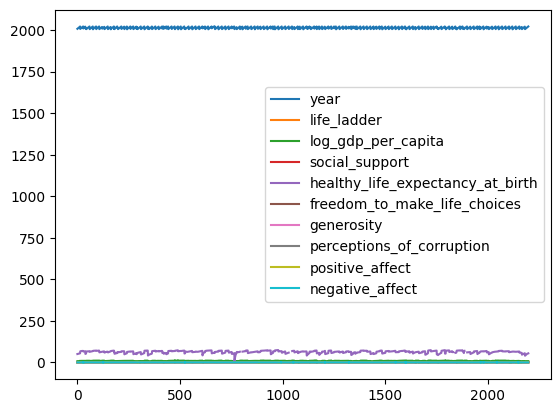

In [32]:
df.plot()

As we can see, in this case the plot is not very useful. The index does not have any specific meaning, and the values of various columns differ greatly (years are all around 2000, but the values in the other columns are much lower) and thus we cannot see much in the plot.  
It is much better to select specific x and y to plot.

<Axes: xlabel='log_gdp_per_capita', ylabel='life_ladder'>

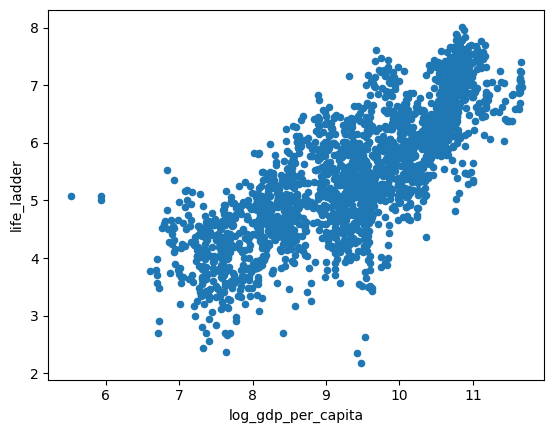

In [33]:
df.plot(kind='scatter', x='log_gdp_per_capita', y='life_ladder')

we can see that there is some sort of trend between the wealth of the country and the happiness of the population and we can say that it looks like that wealthier people are to some extent happier. 

Sometimes it is very insightful to separate the points by colors to highlight different characteristics or some points we are most interested in. Take a look at the example below

<Axes: xlabel='log_gdp_per_capita', ylabel='life_ladder'>

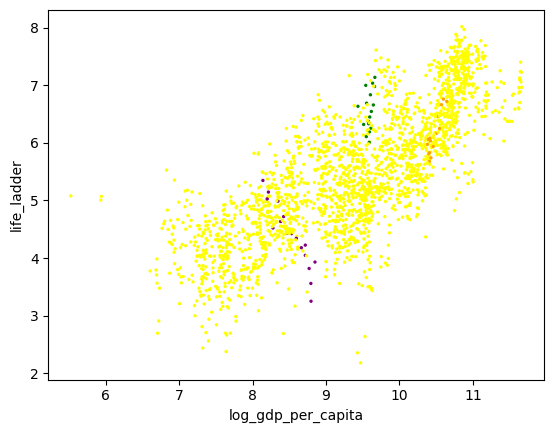

In [34]:
# Create a dictionary to map the country names to colors
cmap = {
    'Brazil': 'Green',
    'Slovenia': 'Orange',
    'India': 'purple'
}

df.plot(
    kind='scatter',
    x='log_gdp_per_capita',
    y='life_ladder',
    c=[cmap.get(c, 'yellow') for c in df.country_name], # Set the colors
    s=2 # Set the size of the points
    )

we can see that even though in general higher GDP means higher value on the life ladder, this is not an universal truth. Comparing Slovenia (orange) with Brazil (green), we can see that people in Brazil earn less, but are on average happier than Slovenians through the years.

Another very useful task we can do with plots is to visulize the distribution of our data. Create `DataFrame.hist()` on the dataframe we want to plot. Note that if we have many columns in the dataframe, this command will plot a histogram for each of the columns. we can select a single column from the dataframe if we only want to plot that one.

array([[<Axes: title={'center': 'life_ladder'}>]], dtype=object)

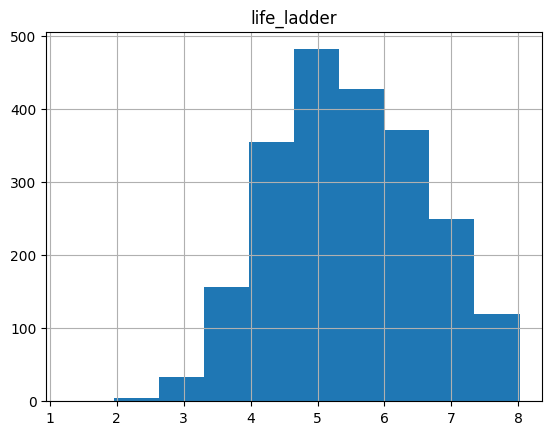

In [35]:
df.hist("life_ladder")

What we see in this histogram is a distribution of values in the "life_ladder" column. What do you think about this distribution on the first glance? Are the people generally happy about their quality of life? Note that to answer this question properly, we need to dig a bit deeper into the data: understand where each value comes from, as the values are not single datapoints (single ansours by people), but already aggregated values across countries and at various points in time.

we can use other external libraries to easily produce various advanced plots. One of such libraries is [Seaborn](https://seaborn.pydata.org/). we have already imported it at the beginning of this lab using `import seaborn as sns`. Since the dataset has many columns it might take a few seconds to run.

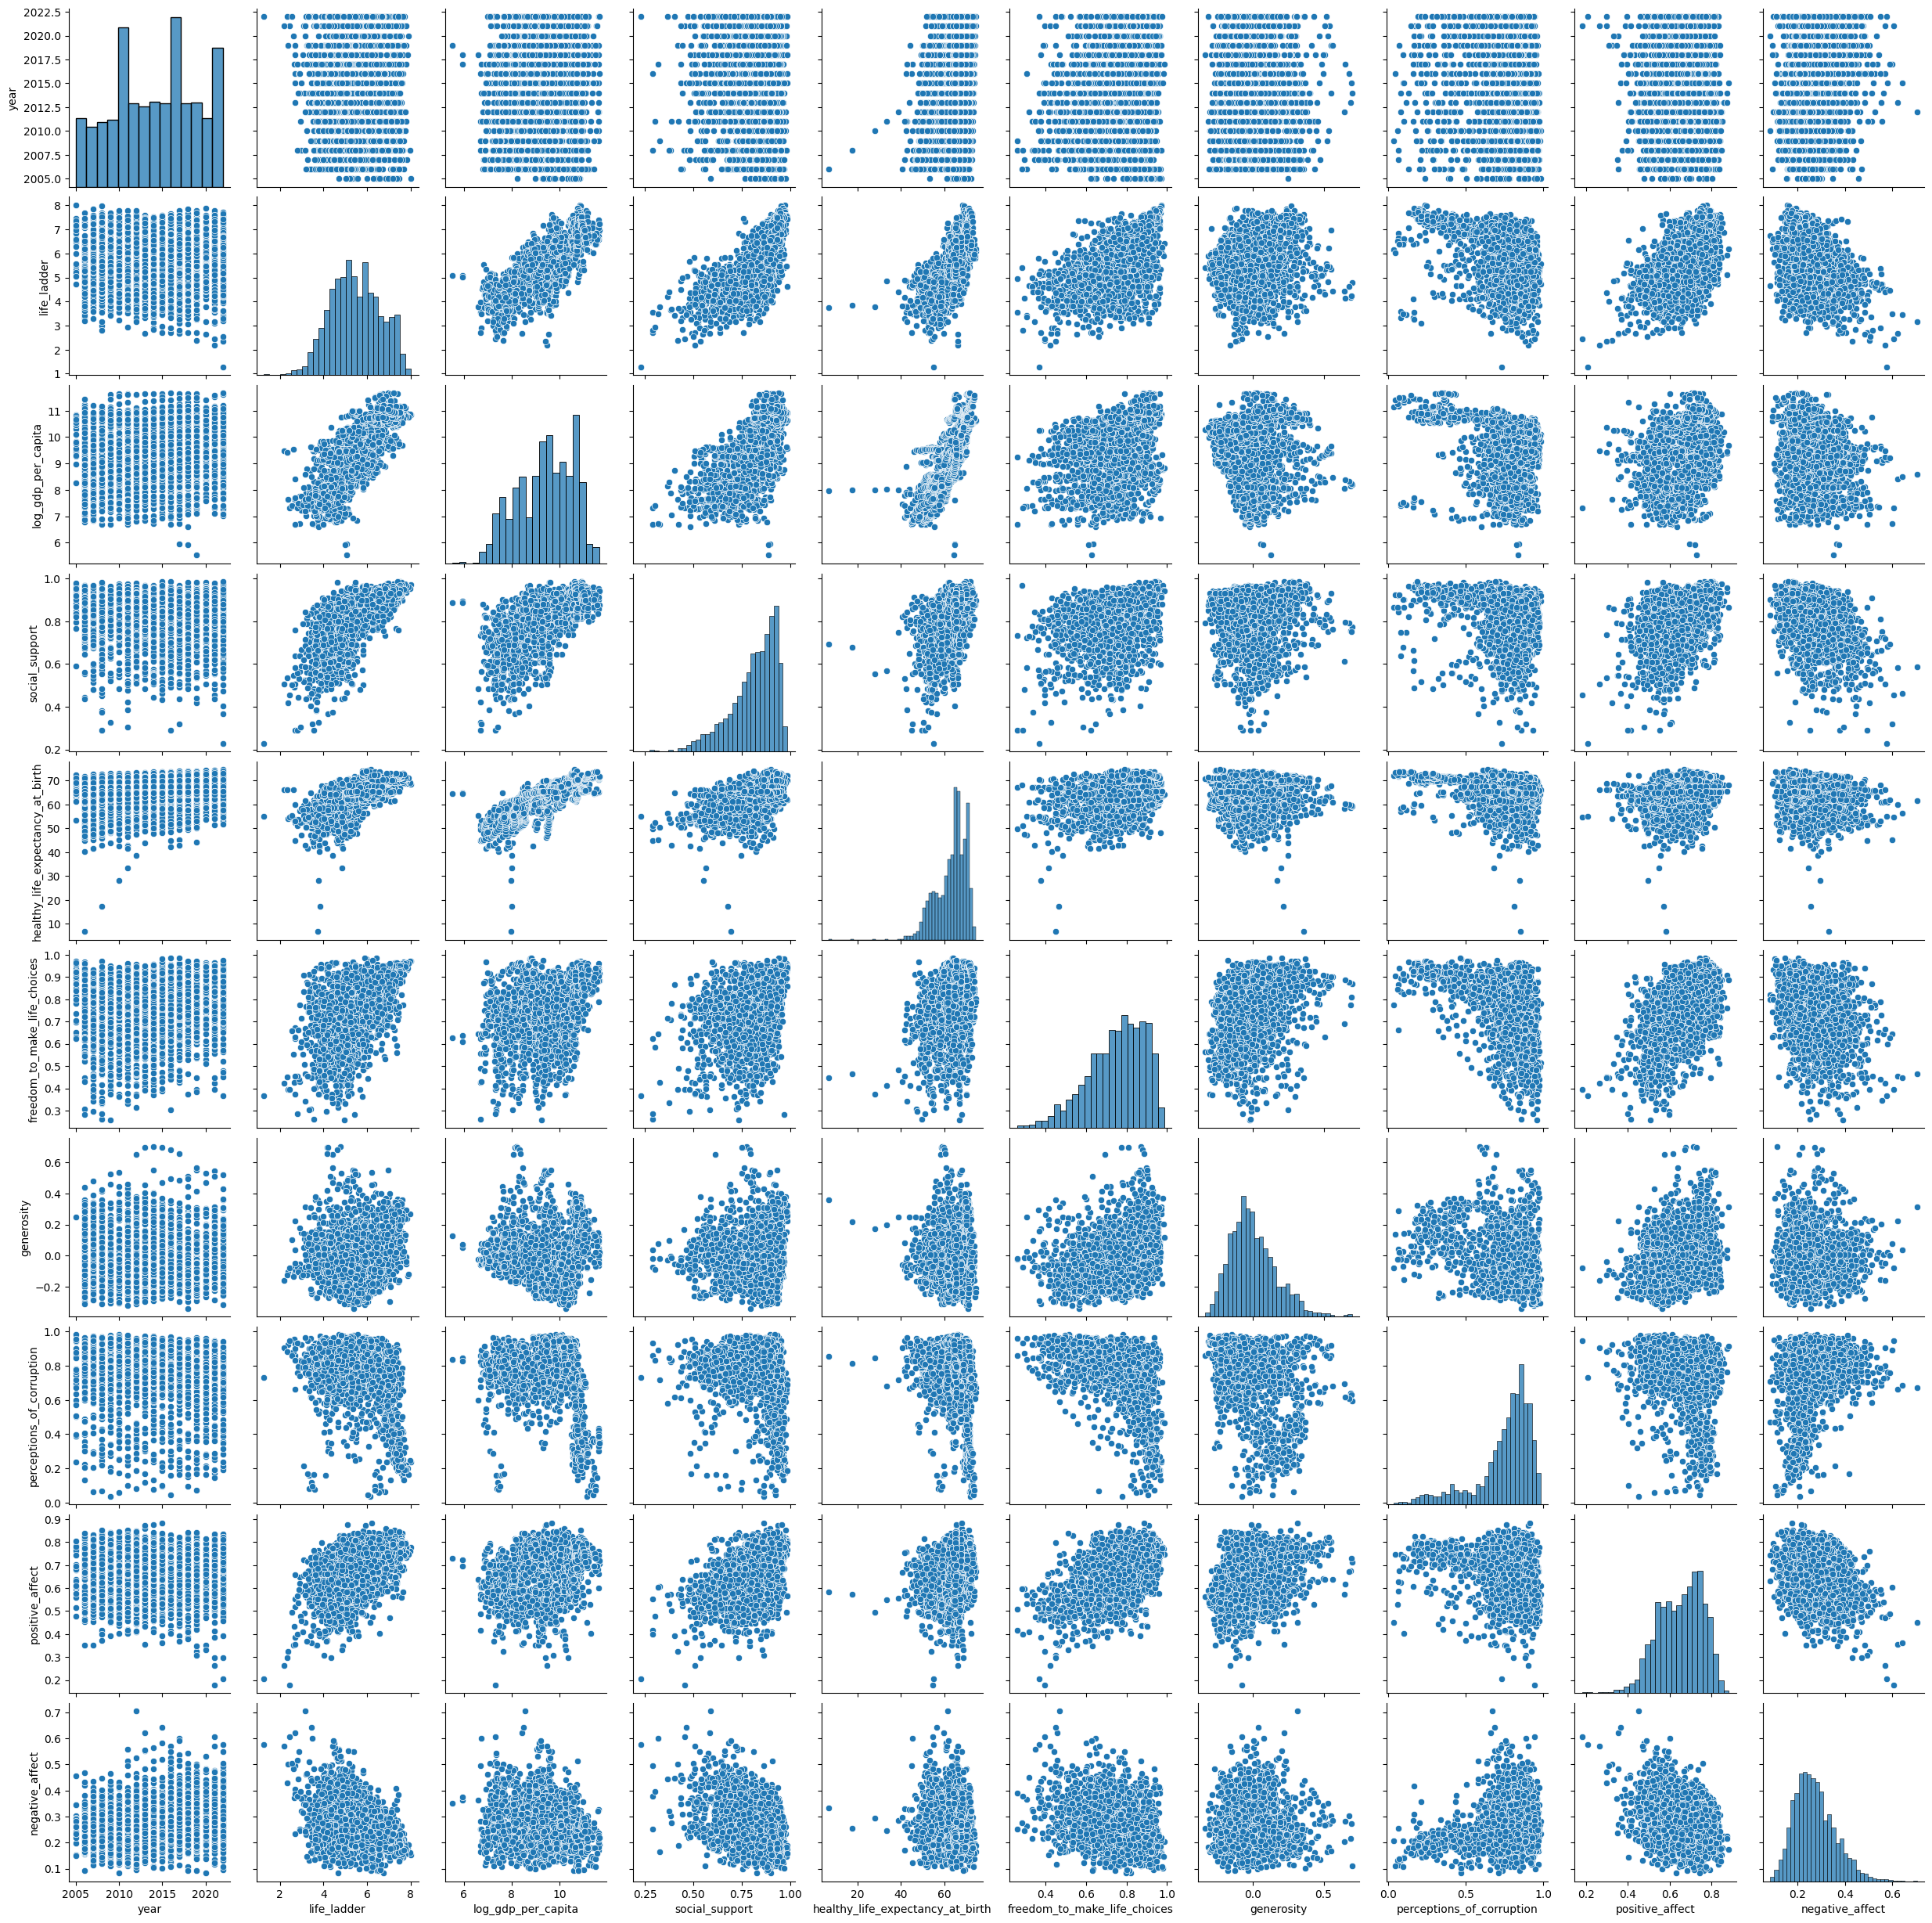

In [ ]:
sns.pairplot(df)

With this kind of plot, we can see pairwise scatter plots for each pair of columns. On the diagonal (where both columns are the same), we don't have a scatter plot (which would only show a line), but a histogram showing the distribution of datapoints.

we can see that both the scatter plots and histograms have very different shapes across columns. Think about various insights we could get from this kind of visualization.

# 6. Operations on Columns
Sometimes the values in the columns are not giving we the information that we need, but there is a way to calculate that information from the values we have.

For example we can create a new column, which is a sum of two columns.

In [37]:
# Create a new column which is the sum of the year and the value on the life ladder.
df["this_column_makes_no_sense"] = df["year"] + df["life_ladder"]
# Create a new column which is the difference of two columns.
df["net_affect_difference"] = df["positive_affect"] - df["negative_affect"]

df.head()

,country_name,year,life_ladder,log_gdp_per_capita,social_support,healthy_life_expectancy_at_birth,freedom_to_make_life_choices,generosity,perceptions_of_corruption,positive_affect,negative_affect,this_column_makes_no_sense,net_affect_difference
0,Afghanistan,2008,3.724,7.350,0.451,50.5,0.718,0.168,0.882,0.414,0.258,2011.724,0.156
1,Afghanistan,2009,4.402,7.509,0.552,50.8,0.679,0.191,0.850,0.481,0.237,2013.402,0.244
2,Afghanistan,2010,4.758,7.614,0.539,51.1,0.600,0.121,0.707,0.517,0.275,2014.758,0.242
3,Afghanistan,2011,3.832,7.581,0.521,51.4,0.496,0.164,0.731,0.480,0.267,2014.832,0.213
4,Afghanistan,2012,3.783,7.661,0.521,51.7,0.531,0.238,0.776,0.614,0.268,2015.783,0.346


Above we can see our dataframe with both new columns. The first one doesn't make much sense, it's just adding the year to the life ladder. The second one, however, find the net difference between positive and negative affect. Perhaps there's an interesting set of patterns between this new column and other columns that we'd now be able to explore. What other columns might we want to calculate? In general, the ability to create new columns using operations on existing columns can be a powerful tool.

If we want to perform some more advanced operations on columns, we can use `DataFrame.apply()`, with which we can apply practically any function to a column. Below we can see how to use the `DataFrame.apply()` in various ways. Try to edit `my_function` to perform an operation of our choice.

In [38]:
# Using df.apply() with a lambda function
# Rescale the life_ladder column to values between 0 and 1 and save it to a new column
df['life_ladder_rescaled'] = df['life_ladder'].apply(lambda x: x / 10)

# Using df.apply() with our own function
# First define a function. The function can do whatever we want. This example will double the column's values
def my_function(x):
    # do stuff to x
    y = x * 2
    return y
# Apply the function.
df['my_function'] = df['life_ladder'].apply(my_function)

# Show the new dataframe
df.head()

,country_name,year,life_ladder,log_gdp_per_capita,social_support,healthy_life_expectancy_at_birth,freedom_to_make_life_choices,generosity,perceptions_of_corruption,positive_affect,negative_affect,this_column_makes_no_sense,net_affect_difference,life_ladder_rescaled,my_function
0,Afghanistan,2008,3.724,7.350,0.451,50.5,0.718,0.168,0.882,0.414,0.258,2011.724,0.156,0.3724,7.448
1,Afghanistan,2009,4.402,7.509,0.552,50.8,0.679,0.191,0.850,0.481,0.237,2013.402,0.244,0.4402,8.804
2,Afghanistan,2010,4.758,7.614,0.539,51.1,0.600,0.121,0.707,0.517,0.275,2014.758,0.242,0.4758,9.516
3,Afghanistan,2011,3.832,7.581,0.521,51.4,0.496,0.164,0.731,0.480,0.267,2014.832,0.213,0.3832,7.664
4,Afghanistan,2012,3.783,7.661,0.521,51.7,0.531,0.238,0.776,0.614,0.268,2015.783,0.346,0.3783,7.566
